In [1]:
import sys 
sys.path.append("..") 
from ThirstyFLOPS.embodied import CPU_embodied, GPU_embodied, memory_embodied, SSD_embodied, HDD_embodied

### Marconi 
1960 CPU: IBM Power9 AC922 

3920 GPU:  Nvidia V100 

256*980 GB DRAM

8* 1024 *1024 GB HDD

1.6tb * 980 * 1024 GB SSD


In [2]:
marconi_CPU = CPU_embodied(location="GlobalFoundries", node = 14, yield_rate=0.875, die_area=693, CPU_memory=0.1, IC_CPU=20)*1960
marconi_GPU = GPU_embodied(location="TSMC", node = 12, yield_rate=0.875, die_area=815, GPU_memory=32, IC_GPU=26)*3920
marconi_memory = memory_embodied(DRAM_size = 256*980)
marconi_HDD = HDD_embodied(8*1024*1024)
marconi_SSD= SSD_embodied(1.6*980*1024)

### Fugaku
158976 CPU: A64FX 48C

4.85 * 1024 * 1024 GB DRAM

150 * 1024 * 1024 GB HDD

158,976 *1.6*1024/16 GB SSD


In [3]:
fugaku_CPU = CPU_embodied(location="TSMC", node = 7, yield_rate=0.875, die_area=400, CPU_memory=0, IC_CPU=20)*158976
fugaku_GPU = 0
fugaku_memory = memory_embodied(DRAM_size =4.85 * 1024 * 1024)
fugaku_HDD = HDD_embodied(150*1024*1024)
fugaku_SSD = SSD_embodied(158976 *1.6*1024/16)



### Polaris
560 CPU: AMD EPYC 7532 CPU

2240 GPU A100 PCIe

280 * 1024 GB DRAM

8 * 1024 * 1024 GB SSD


In [4]:
polaris_CPU = CPU_embodied(location="TSMC", node = 7, yield_rate=0.875, die_area=648, CPU_memory=0, IC_CPU=9)*560
polaris_GPU = GPU_embodied(location="TSMC", node = 7, yield_rate=0.875, die_area=826, GPU_memory=40, IC_GPU=26)*2240
polaris_memory = memory_embodied(DRAM_size = 280*1024)
polaris_SSD = SSD_embodied(8*1024*1024)
polaris_HDD = 0


### Frontier
9480 CPU:AMD EPYC 7763

37632 GPU AMD Instinct MI250X GPU
 
512 *9408 GB DRAM

679 * 1024 * 1024 HDD

9408 * 1.92 * 2 * 1024 GB SSD

In [5]:
frontier_CPU = CPU_embodied(location="TSMC", node = 7, yield_rate=0.875, die_area=648, CPU_memory=0, IC_CPU=9)*9480
frontier_GPU = GPU_embodied(location="TSMC", node = 6, yield_rate=0.875, die_area=724, GPU_memory=128, IC_GPU=26)*37632
frontier_memory = memory_embodied(DRAM_size = 512*9408)
frontier_HDD = HDD_embodied(679*1024*1024)
frontier_SSD = SSD_embodied(9408*1.92*2*1024)

In [6]:
marconi = [marconi_CPU, marconi_GPU, marconi_memory, marconi_HDD, marconi_SSD]
fugaku = [fugaku_CPU, fugaku_GPU, fugaku_memory, fugaku_HDD, fugaku_SSD]
polaris = [polaris_CPU, polaris_GPU, polaris_memory, polaris_HDD, polaris_SSD]
frontier = [frontier_CPU, frontier_GPU, frontier_memory, frontier_HDD, frontier_SSD]
print(sum(frontier), sum(polaris), sum(fugaku), sum(marconi))
polaris_percent = [100*x/sum(polaris) for x in polaris]
fugaku_percent = [100*x/sum(fugaku) for x in fugaku]
marconi_percent = [100*x/sum(marconi) for x in marconi]
frontier_percent = [100*x/sum(frontier) for x in frontier]

45359377.22112001 1264650.0096 32753207.00928 1647948.56192


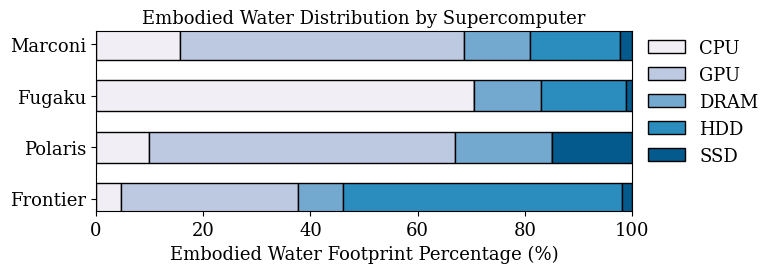

In [7]:
import matplotlib.pyplot as plt
plt.rcParams.update({'mathtext.default':  'regular' })
FONTSIZE = 13
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(nrows=1, ncols=1, gridspec_kw={'hspace': 0.4, 'wspace': 0.2, 'bottom': 0.2, 
                        'top': 0.8, 'right':0.995, 'left':0.17}, figsize=(6.5,3), sharey=True)
labels = ["Frontier","Polaris","Fugaku","Marconi"]
segments = ["CPU","GPU","DRAM","HDD","SSD"]
data = [frontier_percent, polaris_percent, fugaku_percent, marconi_percent]
colors = ["#f1eef6","#bdc9e1","#74a9cf","#2b8cbe","#045a8d"]



y_positions = range(len(labels))

for i, (label, values) in enumerate(zip(labels, data)):
    left = 0  
    for j, (val, color) in enumerate(zip(values, colors)):
        ax.barh(y_positions[i], val, left=left, color=color, edgecolor="black", height=0.6)
        left += val

ax.set_yticks(list(y_positions))
ax.set_yticklabels(labels)
ax.set_xlabel("Embodied Water Footprint Percentage (%)", fontsize=FONTSIZE)
ax.set_title("Embodied Water Distribution by Supercomputer", fontsize=FONTSIZE)
patches = [plt.Rectangle((0, 0), 1, 1, facecolor=color, edgecolor='black') for color in colors]
led = ax.legend(patches, segments, bbox_to_anchor=(1, 1.05), loc='upper left', frameon=False, fontsize=FONTSIZE)
ax.set_xlim(0,100)
ax.set_ylim(-0.25, len(labels)-0.75)
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE)
plt.savefig("../figures/figure3.pdf", bbox_inches="tight")
